In [1]:
import scanpy as sc

In [2]:
adata = sc.read_h5ad("DICTY_snapTotal.h5ad")

/opt/anaconda3/envs/total_scRNA_310/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(


In [3]:
print(adata.X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 136353 stored elements and shape (25, 13375)>
  Coords	Values
  (0, 2)	1.0
  (0, 23)	1.0
  (0, 33)	2.0
  (0, 35)	1.0
  (0, 51)	1.0
  (0, 58)	1.0
  (0, 71)	16.0
  (0, 75)	14.0
  (0, 78)	93.0
  (0, 79)	29.0
  (0, 81)	118.0
  (0, 82)	269.0
  (0, 83)	1.0
  (0, 84)	203.0
  (0, 85)	7.0
  (0, 86)	59.0
  (0, 87)	7.0
  (0, 88)	2.0
  (0, 89)	7.0
  (0, 91)	518.0
  (0, 92)	29.0
  (0, 93)	43.0
  (0, 94)	15.0
  (0, 95)	5.0
  (0, 96)	4.0
  :	:
  (24, 13285)	2.0
  (24, 13288)	1.0
  (24, 13290)	1.0
  (24, 13295)	2.0
  (24, 13296)	1.0
  (24, 13298)	1.0
  (24, 13299)	1.0
  (24, 13300)	1.0
  (24, 13303)	1.0
  (24, 13305)	4.0
  (24, 13310)	4.0
  (24, 13319)	9.0
  (24, 13320)	4.0
  (24, 13321)	2.0
  (24, 13329)	1.0
  (24, 13330)	1.0
  (24, 13332)	1.0
  (24, 13341)	2.0
  (24, 13342)	1.0
  (24, 13347)	1.0
  (24, 13350)	1.0
  (24, 13355)	1.0
  (24, 13365)	8.0
  (24, 13366)	2.0
  (24, 13371)	14.0


In [4]:
adata

AnnData object with n_obs × n_vars = 25 × 13375
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'RNA_snn_res.0.4', 'seurat_clusters', 'nCount_unspliced', 'nFeature_unspliced', 'nCount_spliced', 'nFeature_spliced'
    var: 'features', 'spliced_features', 'unspliced_features'
    uns: 'neighbors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'spliced', 'unspliced'
    obsp: 'distances'

In [5]:
remove = ["DDB-G0295649","DDB-G0295655","DDB-G0295651","DDB-G0295653","DDB-G0295643","DDB-G0295641","DDB-G0295647","DDB-G0295645"]
mask = ~adata.var["features"].isin(remove)
adata = adata[:, mask].copy()


In [6]:
import scvelo as scv
scv.pp.normalize_per_cell(adata, enforce=True)
scv.pp.filter_genes_dispersion(adata, n_top_genes=2000)
scv.pp.log1p(adata)
scv.pp.moments(adata, n_pcs=2, n_neighbors=20)

Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
computing neighbors


/var/folders/b0/d34rvffj6l18k2sl5mb16w440000gn/T/ipykernel_93202/1824105468.py:4: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  scv.pp.log1p(adata)
/var/folders/b0/d34rvffj6l18k2sl5mb16w440000gn/T/ipykernel_93202/1824105468.py:5: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata, n_pcs=2, n_neighbors=20)
/opt/anaconda3/envs/total_scRNA_310/lib/python3.10/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(


    finished (0:00:03) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [7]:
scv.tl.recover_dynamics(adata, fit_basal_transcription=True, n_jobs=12)
scv.tl.velocity(adata, mode='dynamical')
scv.tl.velocity_graph(adata)

recovering dynamics (using 12/12 cores)


  0%|          | 0/62 [00:00<?, ?gene/s]

    finished (0:00:02) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/12 cores)


  0%|          | 0/25 [00:00<?, ?cells/s]

    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


In [8]:
sc.pp.neighbors(adata)
sc.tl.pca(adata)

computing velocity embedding
    finished (0:00:00) --> added
    'velocity_pca', embedded velocity vectors (adata.obsm)


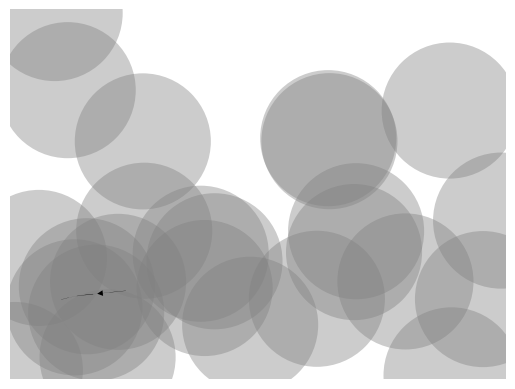

In [9]:
scv.pl.velocity_embedding_stream(adata, basis='pca', alpha=0.4, n_neighbors=3)

In [10]:
adata.obsm["velocity_pca"]

array([[-7.98123344e-01, -1.37399742e-01,  2.58114938e-01,
        -5.07884068e-03, -1.31104875e-01, -5.07026238e-02,
         9.22094676e-02, -5.07484807e-02, -3.02817933e-02,
        -3.87025270e-02, -6.72075286e-03,  2.31515994e-01,
         1.07984872e-01,  7.48920466e-02, -1.22994569e-01,
         1.89593031e-01, -1.62727906e-01, -2.93040717e-02,
         2.37017227e-01,  1.17393177e-01, -1.46538091e-01,
         1.80001755e-01, -1.19878945e-01,  1.66553974e-01],
       [-7.63543856e-01, -1.17819728e-01,  2.34786216e-01,
        -3.33498367e-03, -1.14327484e-01, -3.58885045e-02,
         7.13343303e-02, -5.52258525e-02, -2.09499179e-02,
        -2.57809170e-02, -8.27181809e-03,  1.79759676e-01,
         8.08006023e-02,  6.88377940e-02, -1.05682363e-01,
         1.91514410e-01, -1.47197572e-01, -1.95916718e-02,
         2.31014628e-01,  9.13947732e-02, -1.30782486e-01,
         1.63340040e-01, -7.79610833e-02,  4.85253917e-02],
       [-9.90777221e-01, -1.96294669e-01,  3.85168296e

In [11]:
adata

AnnData object with n_obs × n_vars = 25 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'RNA_snn_res.0.4', 'seurat_clusters', 'nCount_unspliced', 'nFeature_unspliced', 'nCount_spliced', 'nFeature_spliced', 'n_counts', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'velocity_self_transition'
    var: 'features', 'spliced_features', 'unspliced_features', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'fit_r2', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling', 'velocity_genes'
    uns: 'neighbors', 'log1p', 'recover_dynamics', 'velocity_params', 'velocity_graph', 'velocity_graph_neg', 'pca'
    obsm: 'X_pca', 'velocity_pca'
    varm: 'PCs', 'loss'
    layers: 'spliced', 'unspliced', 'Ms', 'Mu', 'fit_t', 'fit_tau', 'fit_tau_', 'velocity', 'velocity_u'
    obs